In [ ]:
import numpy as np

In [2]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [5]:
df=pd.read_csv("matches.csv")

In [6]:
df.shape

(636, 18)

In [7]:
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,5/4/2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,6/4/2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,7/4/2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,8/4/2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,8/4/2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [8]:
df.tail()


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
631,632,2016,Raipur,22/05/16,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,6,V Kohli,Shaheed Veer Narayan Singh International Stadium,A Nand Kishore,BNJ Oxenford,NaN
632,633,2016,Bangalore,24/05/16,Gujarat Lions,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,4,AB de Villiers,M Chinnaswamy Stadium,AK Chaudhary,HDPK Dharmasena,NaN
633,634,2016,Delhi,25/05/16,Sunrisers Hyderabad,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Sunrisers Hyderabad,22,0,MC Henriques,Feroz Shah Kotla,M Erasmus,C Shamshuddin,NaN
634,635,2016,Delhi,27/05/16,Gujarat Lions,Sunrisers Hyderabad,Sunrisers Hyderabad,field,normal,0,Sunrisers Hyderabad,0,4,DA Warner,Feroz Shah Kotla,M Erasmus,CK Nandan,NaN
635,636,2016,Bangalore,29/05/16,Sunrisers Hyderabad,Royal Challengers Bangalore,Sunrisers Hyderabad,bat,normal,0,Sunrisers Hyderabad,8,0,BCJ Cutting,M Chinnaswamy Stadium,HDPK Dharmasena,BNJ Oxenford,NaN


In [9]:
df.dtypes

id                   int64
season               int64
city                   str
date                   str
team1                  str
team2                  str
toss_winner            str
toss_decision          str
result                 str
dl_applied           int64
winner                 str
win_by_runs          int64
win_by_wickets       int64
player_of_match        str
venue                  str
umpire1                str
umpire2                str
umpire3            float64
dtype: object

In [10]:
df.isna().any()

id                 False
season             False
city                True
date               False
team1              False
team2              False
toss_winner        False
toss_decision      False
result             False
dl_applied         False
winner              True
win_by_runs        False
win_by_wickets     False
player_of_match     True
venue              False
umpire1             True
umpire2             True
umpire3             True
dtype: bool

In [11]:
Sum_train = df.isnull().sum()
Percentage = ( df.isnull().sum()/df.isnull().count())
pd.concat([Sum_train,Percentage], axis =1, keys= ['Sum', 'Percentage'])

,Sum,Percentage
id,0,0.000000
season,0,0.000000
city,7,0.011006
date,0,0.000000
team1,0,0.000000
team2,0,0.000000
toss_winner,0,0.000000
toss_decision,0,0.000000
result,0,0.000000
dl_applied,0,0.000000


In [12]:
df.drop(['umpire3'], axis=1,inplace=True)

In [13]:
features = [
    "season",
    "city",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "venue"
]

target = "winner"

In [14]:
model_df = df[features + [target]].dropna()

print(model_df.shape)

(626, 8)


In [15]:
X = model_df[features]
y = model_df[target]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head(5))


Features:
   season       city                        team1  \
0    2017  Hyderabad          Sunrisers Hyderabad   
1    2017       Pune               Mumbai Indians   
2    2017     Rajkot                Gujarat Lions   
3    2017     Indore       Rising Pune Supergiant   
4    2017  Bangalore  Royal Challengers Bangalore   

                         team2                  toss_winner toss_decision  \
0  Royal Challengers Bangalore  Royal Challengers Bangalore         field   
1       Rising Pune Supergiant       Rising Pune Supergiant         field   
2        Kolkata Knight Riders        Kolkata Knight Riders         field   
3              Kings XI Punjab              Kings XI Punjab         field   
4             Delhi Daredevils  Royal Challengers Bangalore           bat   

                                       venue  
0  Rajiv Gandhi International Stadium, Uppal  
1    Maharashtra Cricket Association Stadium  
2     Saurashtra Cricket Association Stadium  
3                   

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "city",
    "team1",
    "team2",
    "toss_winner",
    "toss_decision",
    "venue"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [17]:
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,5/4/2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,6/4/2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,7/4/2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,8/4/2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,8/4/2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (500, 7)
Testing data: (126, 7)


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000
    ))
])

In [20]:
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


c:\Users\i-bhakti.patel\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['Delhi Daredevils' 'Rajasthan Royals' 'Mumbai Indians' 'Delhi Daredevils'
 'Mumbai Indians' 'Kings XI Punjab' 'Chennai Super Kings'
 'Sunrisers Hyderabad' 'Chennai Super Kings' 'Delhi Daredevils']


In [22]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 0.4444444444444444
Accuracy: 44.44 %


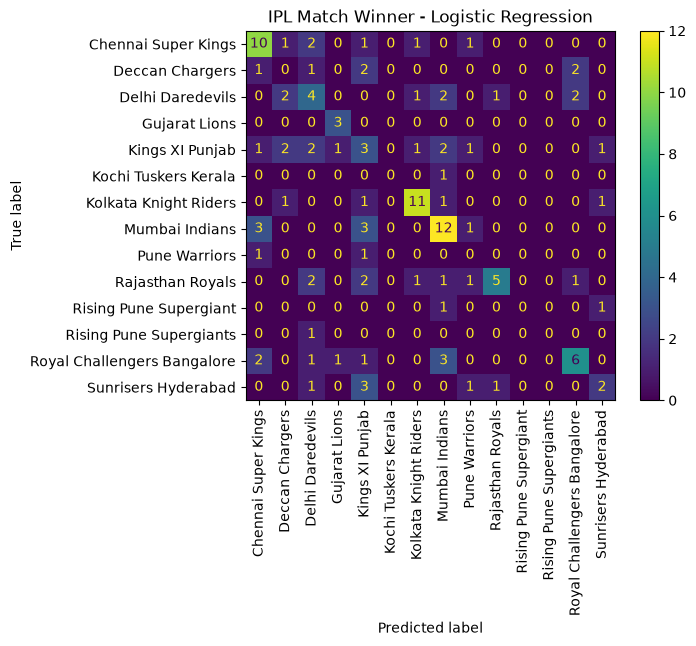

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=90
)

plt.title("IPL Match Winner - Logistic Regression")
plt.show()

In [24]:
probabilities = model.predict_proba(X_test)

print(probabilities[0])

[0.29577327 0.01274881 0.57382093 0.00739275 0.02083888 0.00781966
 0.0170532  0.0206019  0.0093099  0.00589499 0.00504949 0.00420999
 0.01614525 0.00334097]


In [25]:
classes = model.named_steps["classifier"].classes_

for team, probability in zip(classes, probabilities[0]):
    print(team, ":", round(probability * 100, 2), "%")

Chennai Super Kings : 29.58 %
Deccan Chargers : 1.27 %
Delhi Daredevils : 57.38 %
Gujarat Lions : 0.74 %
Kings XI Punjab : 2.08 %
Kochi Tuskers Kerala : 0.78 %
Kolkata Knight Riders : 1.71 %
Mumbai Indians : 2.06 %
Pune Warriors : 0.93 %
Rajasthan Royals : 0.59 %
Rising Pune Supergiant : 0.5 %
Rising Pune Supergiants : 0.42 %
Royal Challengers Bangalore : 1.61 %
Sunrisers Hyderabad : 0.33 %


In [26]:
df["team1"].unique()


<StringArray>
[        'Sunrisers Hyderabad',              'Mumbai Indians',
               'Gujarat Lions',      'Rising Pune Supergiant',
 'Royal Challengers Bangalore',       'Kolkata Knight Riders',
            'Delhi Daredevils',             'Kings XI Punjab',
         'Chennai Super Kings',            'Rajasthan Royals',
             'Deccan Chargers',        'Kochi Tuskers Kerala',
               'Pune Warriors',     'Rising Pune Supergiants']
Length: 14, dtype: str

In [27]:
df["team2"].unique()

<StringArray>
['Royal Challengers Bangalore',      'Rising Pune Supergiant',
       'Kolkata Knight Riders',             'Kings XI Punjab',
            'Delhi Daredevils',         'Sunrisers Hyderabad',
              'Mumbai Indians',               'Gujarat Lions',
            'Rajasthan Royals',         'Chennai Super Kings',
             'Deccan Chargers',               'Pune Warriors',
        'Kochi Tuskers Kerala',     'Rising Pune Supergiants']
Length: 14, dtype: str

In [28]:
team_mapping = {
    "Mumbai Indians": 0,
    "Chennai Super Kings": 1,
    "Royal Challengers Bangalore": 2,
    "Kolkata Knight Riders": 3,
    "Rajasthan Royals": 4,
    "Delhi Daredevils": 5,
    "Kings XI Punjab": 6,
    "Sunrisers Hyderabad": 7,
    "Gujarat Lions": 8,
    "Rising Pune Supergiant": 9
}

In [29]:
df["team1"] = df["team1"].map(team_mapping)
df["team2"] = df["team2"].map(team_mapping)
df["toss_winner"] = df["toss_winner"].map(team_mapping)
df["winner"] = df["winner"].map(team_mapping)

In [30]:
df[["team1", "team2", "toss_winner", "winner"]].head()

,team1,team2,toss_winner,winner
0,7.0,2.0,2.0,7.0
1,0.0,9.0,9.0,9.0
2,8.0,3.0,3.0,3.0
3,9.0,6.0,6.0,6.0
4,2.0,5.0,2.0,2.0


In [31]:
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,5/4/2017,7.0,2.0,2.0,field,normal,0,7.0,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,6/4/2017,0.0,9.0,9.0,field,normal,0,9.0,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,7/4/2017,8.0,3.0,3.0,field,normal,0,3.0,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,8/4/2017,9.0,6.0,6.0,field,normal,0,6.0,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,8/4/2017,2.0,5.0,2.0,bat,normal,0,2.0,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN
